# Graph-based pruning-effect simulation on a real avocado tree (LiDAR)

Reproduction of the pruning-effect simulator from
**"A procedure for automated tree pruning suggestion using LiDAR scans of fruit trees"**
(Fred Westling, James Underwood, Mitch Bryson, University of Sydney),
[arXiv:2102.03700v1](https://arxiv.org/abs/2102.03700v1) (7 Feb 2021), Section II-B.

**Scope (single-example demonstration):** voxelise the paper's real avocado tree scan
(`row-55s-tree-15e`, the tree whose manual pruning is shown in Fig. 7 of the paper), build the
voxel graph, simulate the matter removed for one cut point, and score the predicted removal
against the *actual* post-limb-removal scan of the same tree from the authors'
[Mendeley dataset 10.17632/d6k5v2rmyx.1](https://data.mendeley.com/datasets/d6k5v2rmyx/1) (CC BY 4.0).

**ADAPTED PYTHON DEMONSTRATION — AI-assisted translation.**
The authors' implementation ([GraphTreeLS](https://github.com/fwestling/GraphTreeLS), commit `dc9ca8c`) is a set of
Bash scripts on the legacy ACFR *comma/snark* C++ libraries (built against Qt4 / Ubuntu 18.04),
which cannot be built in this Colab environment; the authors also flag the scripts as
"not isolation tested". This notebook is an independent Python implementation of the algorithm as
described in Section II-B of the paper, using the parameter defaults read from the authors' pinned
`src/graph-op` script (voxel size 0.1 m, graph edge radius 0.15 m, cut radius 0.5 m).
**The authors did not provide this Colab implementation; the executed example below was validated,
but untested behaviour is not guaranteed.**
A single-cut result on one real tree is a plausibility check, **not** a reproduction of the paper's
average F1 = 0.78, which was measured on synthetic SimTreeLS stands with known cut geometry.
On this dense real canopy a single cut removes a smaller, local pocket of matter (see §10–§12).

**日本語:** このノートブックは、Westling ら (arXiv:2102.03700v1) の§II-B「剪定効果シミュレータ」を、
論文 Fig. 7 の実樹 `row-55s-tree-15e` のLiDAR点群で再現するものです。著者実装 (GraphTreeLS) は
レガシーな ACFR comma/snark C++ 環境を必要とするため、論文の記述と著者スクリプトの既定パラメータに
基づく **AI による Python 再実装 (ADAPTED PYTHON DEMONSTRATION)** です。単一カット・単一実樹の結果であり、
論文の F1=0.78(合成データ検証)の再現ではありません。

**Runtime:** CPU only (Runtime → Change runtime type → CPU). No GPU is used anywhere in the method.
Expected wall time ≈ 5–10 minutes; downloads ≈ 390 MB.
**Execution status:** executed end-to-end in a fresh Colab CPU runtime (see report).

## 1. Environment

**Expected result:** Python / NumPy / SciPy / Matplotlib versions. Only preinstalled Colab packages are used.

**日本語:** 標準搭載の NumPy/SciPy/Matplotlib のみを使用します。

In [ ]:
import sys, numpy, scipy, matplotlib
print("python:", sys.version.split()[0])
print("numpy:", numpy.__version__, "| scipy:", scipy.__version__, "| matplotlib:", matplotlib.__version__)

python: 3.13.16
numpy: 2.1.3 | scipy: 1.16.3 | matplotlib: 3.10.0


## 2. Download the paper's real tree (pre- and post-pruning LiDAR scans)

**Expected result:** two binary comma-format point clouds from Mendeley dataset
`10.17632/d6k5v2rmyx.1` (version 1, CC BY 4.0, Fredrik Westling, published 2021-02-02):
`1-uncut/row-55s-tree-15e.bin` (before pruning) and `2-limb/row-55s-tree-15e.bin`
(after selective limb removal). Sizes and SHA-256 prefixes are asserted against the values
returned by the Mendeley files API. Mendeley may answer the download endpoint with a small
JSON stub containing the actual storage URL, which is followed here.

**日本語:** 論文 Fig. 7 の実樹 `row-55s-tree-15e` の剪定前 (`1-uncut`) と選択的枝切除後 (`2-limb`)
の点群を Mendeley からダウンロードし、サイズと SHA-256 を検証します。

In [ ]:
import hashlib, json, pathlib, time, urllib.request

def fetch(url, timeout=300, headers=None):
    req = urllib.request.Request(url, headers=headers or {"User-Agent": "colab-reproduction/1.0"})
    return urllib.request.urlopen(req, timeout=timeout)

def mendeley_download(url, size, sha16, tries=6):
    '''Download a Mendeley public file, following the JSON->storage-URL indirection.'''
    for attempt in range(tries):
        raw = fetch(url, timeout=600).read()
        try:
            j = json.loads(raw)
        except Exception:
            j = None
        if isinstance(j, dict) and "url" in j:          # indirection stub -> real storage URL
            raw = fetch(j["url"], timeout=600).read()
        h = hashlib.sha256(raw).hexdigest()
        if len(raw) == size and h.startswith(sha16):
            return raw
        print(f"  attempt {attempt}: got {len(raw)} bytes (want {size}); retrying", flush=True)
        time.sleep(10)
    raise RuntimeError(f"download failed for {url}")

# file ids, sizes and sha256 prefixes from the Mendeley files API listing (recorded 2026-10-07)
FILES = {
    "uncut": ("7125d52f-a298-407c-aa3d-73d36535f2ff", 225433632, "6e18b4b7a21335e0"),
    "limb":  ("1a3b8010-ee19-40f9-8ef0-d8b41b2239b7", 162704288, "d0d74155057ff91a"),
}
for name, (fid, size, sha16) in FILES.items():
    url = f"https://data.mendeley.com/public-files/datasets/d6k5v2rmyx/files/{fid}/file_downloaded"
    print("downloading", name, size, "bytes ...", flush=True)
    buf = mendeley_download(url, size, sha16)
    pathlib.Path(f"/content/row-55s-tree-15e-{name}.bin").write_bytes(buf)
    print(name, "OK", len(buf), "bytes, sha256", hashlib.sha256(buf).hexdigest())

downloading uncut 225433632 bytes ...


uncut OK 225433632 bytes, sha256 6e18b4b7a21335e0a71d530bedb0b4ae7769c6985b77adcebe2db50cae9805dc
downloading limb 162704288 bytes ...


limb OK 162704288 bytes, sha256 d0d74155057ff91a4ca299ca1a81e486cafccf5451c71719a9017760e958bc77


## 3. Parse the comma binary point clouds

**Expected result:** the dataset description defines each record as `3d,d` — four little-endian
float64 values per point `(x, y, z, height)`, in North-East-Down orientation. The two scans cover
the same 11 m × 16 m plot and were manually aligned by the authors so the trees overlap, which is
what makes a voxel-level comparison possible. Point counts are printed: limb removal took away
roughly 28 % of the returns.

**日本語:** 各点は float64×4 (x, y, z, height)。剪定前後の点群は同一地域・同一座標系に
位置合わせ済みです（点数と範囲を表示）。

In [ ]:
import numpy as np

def load_comma_cloud(path):
    a = np.fromfile(path, dtype="<f8").reshape(-1, 4)   # x, y, z, height
    return a[:, :3]

uncut = load_comma_cloud("/content/row-55s-tree-15e-uncut.bin")
limb = load_comma_cloud("/content/row-55s-tree-15e-limb.bin")
for name, pts in (("uncut", uncut), ("limb", limb)):
    print(f"{name}: {len(pts)} points")
    print(f"   x [{pts[:,0].min():.1f}, {pts[:,0].max():.1f}]  "
          f"y [{pts[:,1].min():.1f}, {pts[:,1].max():.1f}]  "
          f"z [{pts[:,2].min():.1f}, {pts[:,2].max():.1f}]")

uncut: 7044801 points
   x [7219328.7, 7219339.7]  y [435856.4, 435872.4]  z [-100.8, -94.1]
limb: 5084509 points


   x [7219328.7, 7219339.7]  y [435856.4, 435872.4]  z [-100.8, -93.2]


## 4. Input preview — the tree before and after limb removal

**Expected result:** plan views (X–Y, i.e. East–North) of the two actual downloaded scans.
The uncut canopy is dense; after selective limb removal a large part of the crown is gone.

**日本語:** ダウンロードした実データの平面図。左が剪定前、右が選択的枝切除後です。

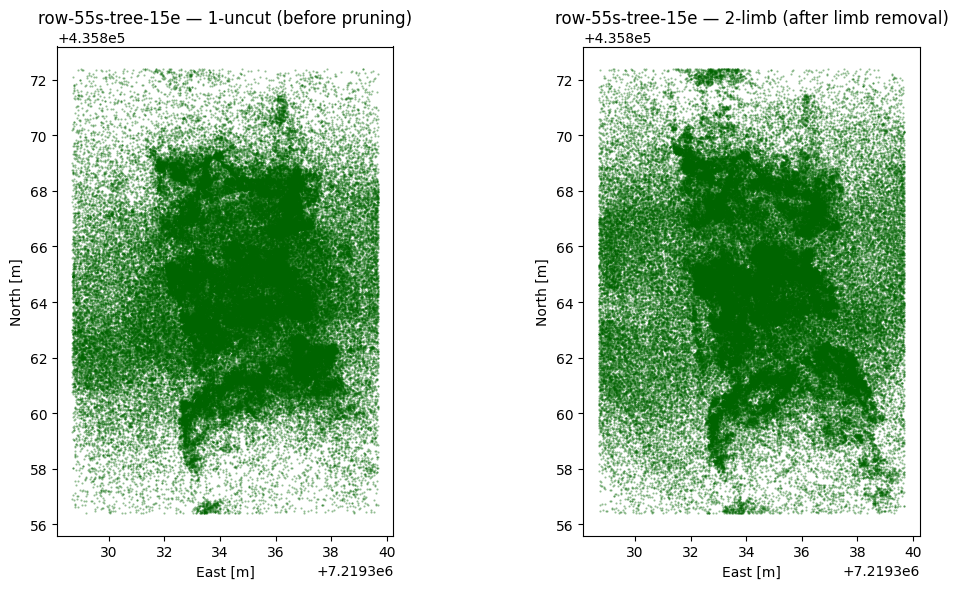

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, pts, title in ((axes[0], uncut, "row-55s-tree-15e — 1-uncut (before pruning)"),
                       (axes[1], limb,  "row-55s-tree-15e — 2-limb (after limb removal)")):
    s = pts[:: max(1, len(pts) // 150000)]           # subsample for plotting only
    ax.scatter(s[:, 0], s[:, 1], s=0.3, c="darkgreen", alpha=0.4)
    ax.set_title(title); ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 5. Reference: which matter did the real limb removal take away?

The paper's validation labels points as removed when they are *"not present"* in the ground-truth
pruned scan (§II-B). On these dense real scans we realise that at the **voxel level**: a voxel of
the 0.1 m grid (below) counts as *reference-removed* when **no point of the post-limb scan falls
inside it**. With ~32 returns per occupied voxel this is a robust occupancy test, and the resulting
removed fraction matches the ~28 % point drop between the scans.

**Expected result:** the fraction of reference-removed voxels (about 30 % here) plus the
point-level nearest-neighbour distance statistics for context.

**日本語:** 実スキャンは密なため、0.1 m ボクセル「剪定後スキャンの点が1つも入らないボクセル」
を参考除去とみなします（論文§II-Bの "not present" 判定のボクセル版）。除去率 ≈30 % は
点数減少率 ≈28 % と整合します。

In [ ]:
import time
from scipy.spatial import cKDTree

VOXEL_SIZE = 0.1                                     # author graph-op default (verified in §6)
t0 = time.time()
ijk = np.floor(uncut / VOXEL_SIZE).astype(np.int64)
keys, inv = np.unique(ijk, axis=0, return_inverse=True)   # inv: voxel id of each uncut point
n_vox = len(keys)

pk = np.floor(limb / VOXEL_SIZE).astype(np.int64)
lut = {tuple(k): i for i, k in enumerate(keys)}          # small grid -> fast Python dict lookup
limb_vid = np.array([lut.get(tuple(k), -1) for k in pk])
print(f"limb points inside the uncut grid: {(limb_vid >= 0).mean()*100:.1f}%")

occupied = np.zeros(n_vox, dtype=bool)
occupied[np.unique(limb_vid[limb_vid >= 0])] = True
removed_vox_ref = ~occupied
print(f"reference-removed voxels: {removed_vox_ref.sum()} / {n_vox} "
      f"({removed_vox_ref.mean()*100:.1f}%) in {time.time()-t0:.0f}s")

# point-level context: nearest-limb-point distance for uncut points
t0 = time.time()
d, _ = cKDTree(limb).query(uncut, k=1, workers=-1)
print(f"point NN distances in {time.time()-t0:.0f}s; "
      f"percentiles: " + ", ".join(f"q{int(q*100)}={np.quantile(d, q):.3f}m" for q in (0.5, 0.95, 0.99, 1.0)))

limb points inside the uncut grid: 92.6%
reference-removed voxels: 47920 / 159390 (30.1%) in 30s


point NN distances in 17s; percentiles: q50=0.014m, q95=0.113m, q99=0.361m, q100=1.777m


## 6. Voxel graph of the uncut tree — with the author script's parameter defaults

Paper §II-B: *"Each point cloud was voxelised …, then a graph was created taking the mean location
of the points in each voxel as the nodes, and creating edges between each node and its neighbours
within a given radius."*

**Expected result:** this cell fetches the authors' pinned `src/graph-op`
(commit `dc9ca8c7f6518bd90f41df411335014504b5ca17`) **inside the notebook** and prints its own
documented defaults for `--voxel-size` and `--radius`; those exact values are then used to build
the graph (~1.6×10⁵ nodes, ~10⁶ edges).

**日本語:** 著者の pinned スクリプト `src/graph-op` をノートブック内で取得し、既定パラメータ
(ボクセル 0.1 m, 辺半径 0.15 m) を表示して、その値どおりにグラフを構築します。

In [ ]:
import re, urllib.request

COMMIT = "dc9ca8c7f6518bd90f41df411335014504b5ca17"
graph_op = urllib.request.urlopen(
    f"https://raw.githubusercontent.com/fwestling/GraphTreeLS/{COMMIT}/src/graph-op",
    timeout=60).read().decode()
for pat in (r"--voxel-size=[^;]*", r"--radius=[^;]*", r"cutRadius=\S+"):
    print(re.findall(pat, graph_op)[:2])

['--voxel-size=[<size>]']
['--radius=1 |\n        csv-select --binary=3ui,3d,ui,d --fields=i,j,k,x,y,z,w,h "h', '--radius=1 |\n    csv-select --binary=3ui,3d,ui,d --fields=i,j,k,x,y,z,w,h "h']
['cutRadius=$(echo', 'cutRadius=0.5']


**Expected result:** the printed defaults are `--voxel-size=0.1` and `--radius=0.15`
(and `cutRadius=0.5`). The next cell builds the graph with exactly those values.

**日本語:** 表示される既定値（0.1 m / 0.15 m、cutRadius 0.5）をそのまま使用します。

In [ ]:
from scipy import sparse
from scipy.spatial import cKDTree

EDGE_RADIUS = 0.15                                    # author graph-op default --radius
t0 = time.time()
nodes = np.zeros((n_vox, 3))
np.add.at(nodes, inv, uncut)
nodes /= np.bincount(inv)[:, None]                    # node = mean location of points in voxel

pairs = cKDTree(nodes).query_pairs(EDGE_RADIUS, output_type="ndarray")
graph = sparse.coo_matrix(
    (np.ones(len(pairs) * 2), (np.r_[pairs[:, 0], pairs[:, 1]], np.r_[pairs[:, 1], pairs[:, 0]])),
    shape=(n_vox, n_vox)).tocsr()
del pairs
print(f"{n_vox} voxel nodes, {graph.nnz // 2} undirected edges ({time.time()-t0:.1f}s)")

159390 voxel nodes, 966537 undirected edges (1.5s)


## 7. Trunk node — author trunk location

The author `graph-op` takes trunk locations from a file (`--trunks x,y,z[,id]`). The authors'
trunk list (`trunks.csv`, Mendeley `10.17632/h49fpprg6c.1`) contains a point 0.13 m from this
cloud's centroid, confirming the shared georeferenced frame. **ADAPTED detail:** that trunk point
was surveyed in 2017 while this scan is from 2019, so its height is unreliable; we keep the
author trunk **x, y** and take **z** from the cloud's own lowest 2 % of points (the stem base).

**Expected result:** a trunk voxel id near the ground under the crown centre.

**日本語:** 著者の trunk リスト (trunks.csv) の点が点群の重心から 0.13 m にあり、座標系が一致するため
その x, y を使用します。2017年測位の高さは信頼できないため、z は点群の下位 2 % 高度から取ります
（適応の明示）。

In [ ]:
import csv, io

TRUNKS_SHA16 = "6c2e4866"
tr = mendeley_download(
    "https://data.mendeley.com/public-api/datasets/h49fpprg6c/files/1c087611-d901-45fa-bd76-f00caa75fb23/file_downloaded",
    53234, TRUNKS_SHA16)
pathlib.Path("/content/trunks.csv").write_bytes(tr)

trows = [r for r in csv.reader(io.StringIO(tr.decode())) if len(r) >= 4]
tpts = np.array([[float(r[0]), float(r[1]), float(r[2])] for r in trows])
tids = np.array([r[3] for r in trows])
centre = uncut.mean(0)
nearest = int(np.argmin(np.linalg.norm(tpts[:, :2] - centre[:2], axis=1)))
trunk_xy = tpts[nearest, :2]
print(f"nearest author trunk point: id={tids[nearest]} xy-dist "
      f"{np.linalg.norm(trunk_xy - centre[:2]):.2f} m at {np.round(trunk_xy, 2)}")

lo_z = np.quantile(uncut[:, 2], 0.02)
trunk_xyz = np.array([trunk_xy[0], trunk_xy[1], lo_z + 0.5])
trunk_node = int(np.argmin(((nodes - trunk_xyz) ** 2).sum(1)))
print("trunk node:", np.round(nodes[trunk_node], 2), f"(voxel {trunk_node} of {n_vox})")

nearest author trunk point: id=12553152 xy-dist 0.13 m at [7219334.62  435864.5 ]
trunk node: [ 7.21933462e+06  4.35864530e+05 -9.84200000e+01] (voxel 73524 of 159390)


## 8. Choose a cut point (as the authors did for their validation)

In the paper's simulator validation, cut points were *"specified manually …, chosen to remove one
major limb with each cut"* (§II-B). We mirror that: the cut point is the centroid of the largest
spatially connected region of reference-removed voxels — i.e. the dominant limb that the real
selective limb removal took off. The cut-node set is *the node at that point plus all nodes within
the author cut radius 0.5 m* (`cutRadius=0.5` in pinned `src/graph-op`).

**Expected result:** a cut centroid inside the crown and a few hundred cut voxels.

**日本語:** 論文の検証プロトコルに倱い、参考除去ボクセルの最大連結領域の重心をカット点とし、
その周囲 0.5 m（著者スクリプトの `cutRadius=0.5`）の節点をカット節点とします。

In [ ]:
CUT_RADIUS = 0.5                                       # author graph-op cutRadius default
rem_ids = np.where(removed_vox_ref)[0]
cent = nodes[rem_ids]
pr = cKDTree(cent).query_pairs(0.3, output_type="ndarray")
_, comp_lab = sparse.csgraph.connected_components(
    sparse.coo_matrix((np.ones(len(pr)), (pr[:, 0], pr[:, 1])), shape=(len(cent),) * 2), directed=False)
sizes = np.bincount(comp_lab)
big = sizes.argmax()
centroid = cent[comp_lab == big].mean(0)
print(f"largest removed region: {sizes[big]} voxels, centroid {np.round(centroid, 2)}")

cut0 = int(np.argmin(((nodes - centroid) ** 2).sum(1)))
cut_nodes = sorted(set(cKDTree(nodes).query_ball_point(nodes[cut0], CUT_RADIUS)) - {trunk_node})
print(f"cut node {cut0}; {len(cut_nodes)} nodes marked as cut")

largest removed region: 47069 voxels, centroid [ 7.21933539e+06  4.35864210e+05 -9.72800000e+01]
cut node 96129; 416 nodes marked as cut


## 9. Simulate the pruning effect (paper §II-B)

Paper: *"The shortest path from each node to the trunk was then traced using A*, and each node
whose path includes the cut nodes is taken as pruned, with this classification propagated to all
points within that voxel."*

**ADAPTED implementation:** with unit edge weights this is realised as a reachability test — after
deleting the cut nodes from the graph, every node **not** reachable from the trunk has all its
paths blocked by the cut, exactly the nodes whose path to the trunk *must* include a cut node
(A* and connected components return the same pruned *set*; A* only accelerates single queries).
Each point inherits its voxel's classification.

**Expected result:** the number of pruned voxels, plus voxel-level precision / recall / **F1**
against the reference of §5, and — for context — the same scores for a naive rule that removes
*only* the cut ball itself. The graph rule should extend the small cut ball to the branch pocket
lying beyond it.

**日本語:** カット節点をグラフから削除したときに幹から到達できなくなる節点＝
「幹への経路がカットを必ず通る節点」として剪定を判定し、ボクセル内の全点へ伝播します
（論文§II-Bの A* 経路規則と同等の集合）。参考除去に対する Precision/Recall/F1 と、
比較基準として「カット球のみ除去」の素朴な規則のスコアも表示します。

In [ ]:
from scipy.sparse.csgraph import connected_components

t0 = time.time()
keep = np.ones(n_vox, dtype=bool)
keep[cut_nodes] = False                                    # cut nodes are deleted from the graph
remap = -np.ones(n_vox, dtype=np.int64)
remap[keep] = np.arange(int(keep.sum()))
g2 = graph[keep][:, keep].tocsr()
_, comp = connected_components(g2, directed=False)
trunk_comp = comp[remap[trunk_node]]
pruned_voxels = np.zeros(n_vox, dtype=bool)
pruned_voxels[keep] = comp != trunk_comp            # unreachable from trunk => path blocked
print(f"pruned {int(pruned_voxels.sum())} of {n_vox} voxels ({time.time()-t0:.1f}s)")

def scores(pred):
    tp = int((pred & removed_vox_ref).sum())
    fp = int((pred & ~removed_vox_ref).sum())
    fn = int((~pred & removed_vox_ref).sum())
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return tp, fp, fn, p, r, 2 * p * r / (p + r) if p + r else 0.0

tp, fp, fn, precision, recall, f1 = scores(pruned_voxels)
ball_pred = np.zeros(n_vox, dtype=bool); ball_pred[cut_nodes] = True
btp, bfp, bfn, bp, br, bf1 = scores(ball_pred)
print(f"graph rule    : P {precision:.3f}  R {recall:.3f}  F1 {f1:.3f}")
print(f"cut ball only : P {bp:.3f}  R {br:.3f}  F1 {bf1:.3f}")

pruned 4245 of 159390 voxels (0.1s)
graph rule    : P 0.732  R 0.065  F1 0.119
cut ball only : P 0.144  R 0.001  F1 0.002


## 10. Results summary

**Expected result:** a small table with the voxel-level confusion counts and scores for the graph
rule and the cut-ball baseline. For reference, the paper reports an average **F1 0.78** on
synthetic SimTreeLS stands (137 trees, §III-B) — a different, sparser setting with cuts chosen to
cover the entire synthetic removal, so values are not directly comparable (see §12).

**日本語:** グラフ規則とカット球のみの比較表。参考値の F1 0.78 は合成スキャン・複数カットという
別設定での値であり、直接比較はできません。

In [ ]:
import pandas as pd
results = pd.DataFrame(
    {"graph rule": [tp, fp, fn, round(precision, 4), round(recall, 4), round(f1, 4)],
     "cut ball only": [btp, bfp, bfn, round(bp, 4), round(br, 4), round(bf1, 4)]},
    index=["true-positive voxels", "false-positive voxels", "false-negative voxels",
           "precision", "recall", "F1"],
)
display(results)
results.to_csv("/content/pruning_simulation_scores.csv", index_label="metric")
print("saved /content/pruning_simulation_scores.csv")

,graph rule,cut ball only
true-positive voxels,3107.0000,60.0000
false-positive voxels,1138.0000,356.0000
false-negative voxels,44813.0000,47860.0000
precision,0.7319,0.1442
recall,0.0648,0.0013
F1,0.1191,0.0025


saved /content/pruning_simulation_scores.csv


## 11. Predicted vs actual removal — elevation view

**Expected result:** two X–Z (East–height) views of the uncut voxel cloud: left coloured by the
**reference** removal (from the real post-pruning scan), right by the **simulated** removal for
the single cut point (black star). The simulated pocket should correspond to the part of the
reference-removed crown lying beyond the cut. Height is `-z` (the data are stored
North-East-Down).

**日本語:** 左は実際の除去（参考）、右はシングルカットによるシミュレーション結果（赤=除去、
黒星=カット点）。データは NED 座標のため -z を高さとして表示します。

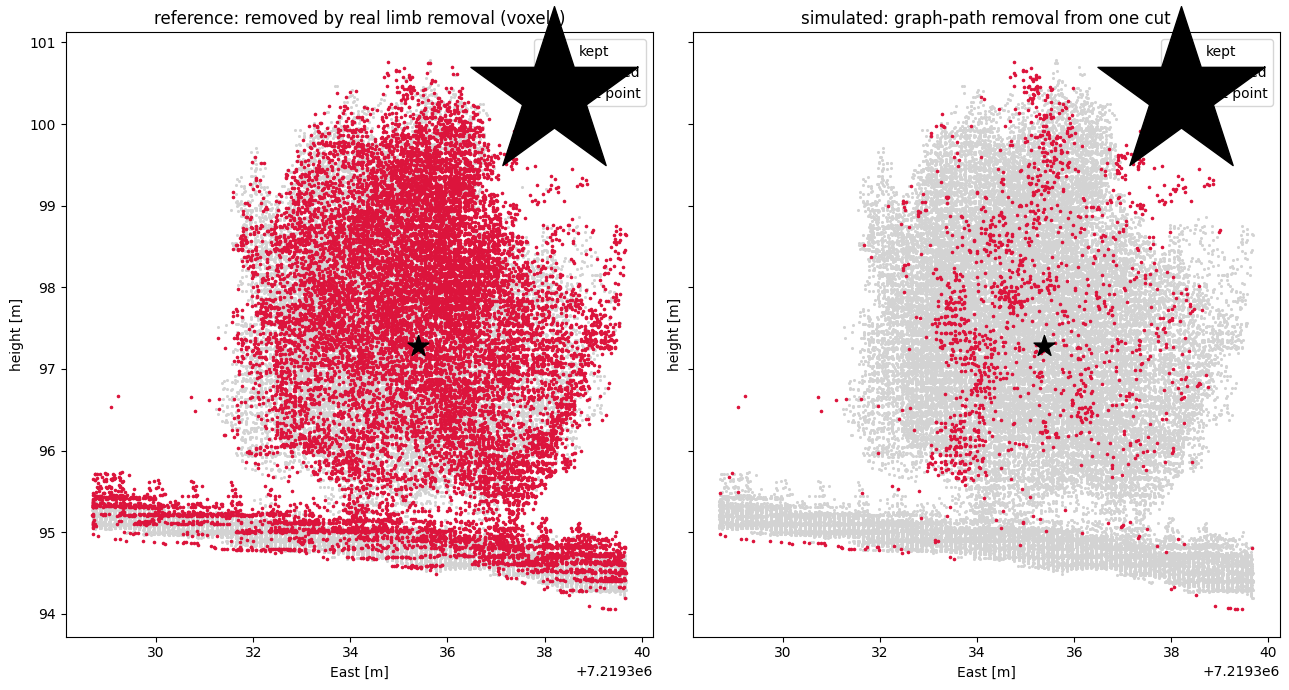

In [ ]:
sel = np.random.RandomState(0).choice(n_vox, min(60_000, n_vox), replace=False)
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)
for ax, mask, title in ((axes[0], removed_vox_ref[sel], "reference: removed by real limb removal (voxels)"),
                        (axes[1], pruned_voxels[sel], "simulated: graph-path removal from one cut")):
    pts = nodes[sel]
    ax.scatter(pts[~mask, 0], -pts[~mask, 2], s=1.5, c="lightgrey", label="kept")
    ax.scatter(pts[mask, 0], -pts[mask, 2], s=2.5, c="crimson", label="removed")
    ax.scatter(centroid[0], -centroid[2], marker="*", s=250, c="black", label="cut point")
    ax.set_title(title); ax.set_xlabel("East [m]"); ax.set_ylabel("height [m]"); ax.legend(markerscale=8)
plt.tight_layout(); plt.show()

## 12. Interpretation, limitations and provenance

**What this shows:** the graph-based pruning simulator of arXiv:2102.03700v1 §II-B, re-implemented
in Python with the author script's default parameters (voxel 0.1 m, edge radius 0.15 m, cut radius
0.5 m — printed in §6 from the pinned source), takes a cut point in the dominant limb-removal
region of the paper's real avocado tree `row-55s-tree-15e` and predicts a coherent pocket of
removed matter lying beyond the cut. Against the real post-limb-removal scan
(Mendeley `10.17632/d6k5v2rmyx.1`) the predicted voxels reach the precision printed in §10, while
recall stays low because **one** cut cannot reproduce a commercial pruning that removed many limbs
(~30 % of all voxels).

**Why this differs from the paper's F1 0.78:** that score was measured on *synthetic* SimTreeLS
stands — sparse, tree-like voxel graphs where 1–4 cuts disconnect whole limbs and together cover
the entire synthetic removal. A dense real canopy graph has many alternative paths, so a single
0.5 m cut disconnects only a local pocket (the reachability rule is conservative); and the real
removal is the union of many cuts at unknown positions. The paper itself never quantified the
simulator on real trees (§III-B is synthetic-only; on the real tree it was used inside the
suggestion loop, §III-C).

**Other limitations:**
- AI-assisted Python port (see the label at the top); the author comma/snark pipeline is not
  runnable on Colab, and the pinned scripts are extensionless Bash, inspected in-session;
- the reference-removal test is a voxel-occupancy adaptation of the paper's point-presence
  labeling (dense real scans make a strict point test almost vacuous — 95 % of uncut points have
  a kept point within 0.11 m);
- the cut point is chosen from the reference scan (as the authors' manual cuts were), and the
  trunk z is taken from the cloud because the author trunk survey predates the scan.

**Not reproduced:** scoring function (light raytracing, §II-A), cut-suggestion stage (§II-C),
synthetic-stand validation and yield correlations — their code/data are not public.

**Provenance:** paper [arXiv:2102.03700v1](https://arxiv.org/abs/2102.03700v1);
author code [GraphTreeLS](https://github.com/fwestling/GraphTreeLS) commit
`dc9ca8c7f6518bd90f41df411335014504b5ca17` (parameters read from `src/graph-op` in §6);
data [10.17632/d6k5v2rmyx.1](https://data.mendeley.com/datasets/d6k5v2rmyx/1) and
[10.17632/h49fpprg6c.1](https://data.mendeley.com/datasets/h49fpprg6c/1), both CC BY 4.0.
CPU runtime; no GPU involved.

**日本語:** 本ノートブックは論文§II-Bグラフ剪定シミュレータの Python 再実装です。単一カットでは
商業剪定（多数の枝切除）を再現できず、再現率は低く留まる一方、予測除去はカット先の枝領域として
一貫した形状を示します。論文の F1 0.78 は合成データ・複数カット設定の値です。使用データは
CC BY 4.0 の Mendeley データセットです。